In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

Using: cuda


In [ ]:
# ============================================
# CONSTANTS
# ============================================
N_grid = 32
q      = 1.0
Vt     = 0.025
mu_n   = 1.0
mu_p   = 1.0
mu_X   = 1.0
k_rec  = 0.1
k_diss = 5.0
G      = 0.1
alpha  = 3.0

In [ ]:
# ============================================
# HELPERS
# ============================================
def make_net(hidden=128):
    net = nn.Sequential(
        nn.Linear(3, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, 1)
    )
    for m in net.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)
    return net

class PINN2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.phi_net = make_net()
        self.n_net   = make_net()
        self.p_net   = make_net()
        self.X_net   = make_net()

    def forward(self, coords, M):
        inp = torch.cat([coords, M], dim=1)
        x   = coords[:, 0:1]
        phi = x  +  x * (1 - x) * self.phi_net(inp)
        n   = (1 - x) * torch.nn.functional.softplus(self.n_net(inp))
        p   = x       * torch.nn.functional.softplus(self.p_net(inp) + 1.0)
        X   =           torch.nn.functional.softplus(self.X_net(inp))
        return phi, n, p, X

def grad(f, coords):
    return torch.autograd.grad(
        f, coords,
        grad_outputs=torch.ones_like(f),
        create_graph=True, retain_graph=True)[0]

def laplacian(f, coords):
    g   = grad(f, coords)
    gxx = grad(g[:, 0:1], coords)[:, 0:1]
    gyy = grad(g[:, 1:2], coords)[:, 1:2]
    return gxx + gyy

def divergence(Fx, Fy, coords):
    return (grad(Fx, coords)[:, 0:1] +
            grad(Fy, coords)[:, 1:2])

def fresh_coords():
    x_lin  = torch.linspace(0, 1, N_grid)
    y_lin  = torch.linspace(0, 1, N_grid)
    Xg, Yg = torch.meshgrid(x_lin, y_lin, indexing='ij')
    c = torch.stack([Xg, Yg], dim=-1).reshape(-1, 2).to(device)
    c.requires_grad_(True)
    return c

def interface_fraction(M):
    h = np.abs(np.diff(M, axis=0)).sum()
    v = np.abs(np.diff(M, axis=1)).sum()
    return (h + v) / M.size

def make_morphology(sigma, seed):
    np.random.seed(seed)
    noise     = np.random.randn(N_grid, N_grid)
    smoothed  = gaussian_filter(noise, sigma=sigma)
    threshold = np.percentile(smoothed, 50)
    return (smoothed > threshold).astype(float)

def compute_all(coords, M_flat, model):
    phi, n, p, X = model(coords, M_flat)

    grad_phi = grad(phi, coords)
    grad_n   = grad(n,   coords)
    grad_p   = grad(p,   coords)
    grad_X   = grad(X,   coords)
    lap_phi  = laplacian(phi, coords)
    lap_X    = laplacian(X,   coords)

    Jn_x = -q*n*mu_n*grad_phi[:,0:1] + q*Vt*mu_n*grad_n[:,0:1]
    Jn_y = -q*n*mu_n*grad_phi[:,1:2] + q*Vt*mu_n*grad_n[:,1:2]
    Jp_x = -q*p*mu_p*grad_phi[:,0:1] - q*Vt*mu_p*grad_p[:,0:1]
    Jp_y = -q*p*mu_p*grad_phi[:,1:2] - q*Vt*mu_p*grad_p[:,1:2]

    div_Jn    = divergence(Jn_x, Jn_y, coords)
    div_Jp    = divergence(Jp_x, Jp_y, coords)
    R         = k_rec  * n * p
    R_X       = k_rec  * X
    field_mag = torch.norm(grad_phi, dim=1, keepdim=True)
    D_term    = k_diss * X * field_mag
    G_field   = G * M_flat

    L_p = torch.mean((lap_phi - q*(n - p))**2)
    L_e = torch.mean((div_Jn  - R + D_term)**2)
    L_h = torch.mean((-div_Jp - R + D_term)**2)
    L_x = torch.mean((Vt*mu_X*lap_X - D_term - R_X + G_field)**2)

    y_c       = coords[:, 1]
    y0        = y_c < (1.0/N_grid)
    y1        = y_c > (1.0 - 1.0/N_grid)
    L_xbc     = (torch.mean(grad_X[y0, 1:2]**2) +
                 torch.mean(grad_X[y1, 1:2]**2))
    L_pbc     = (torch.mean(grad_phi[y0, 1:2]**2) +
                 torch.mean(grad_phi[y1, 1:2]**2))
    L_nd      = torch.mean((n * M_flat)**2)
    L_pd      = torch.mean((p * (1 - M_flat))**2)
    L_cons    = torch.var(Jn_x + Jp_x)

    return (L_p, L_e, L_h, L_x, L_xbc,
            L_pbc, L_nd, L_pd, L_cons, Jn_x, Jp_x)

In [ ]:
# ============================================
# TRAIN AND EVALUATE ONE MORPHOLOGY
# ============================================
def train_and_get_Jsc(M_np, label=""):
    M_flat = torch.tensor(
        M_np.flatten(), dtype=torch.float32
    ).reshape(-1, 1).to(device)

    model = PINN2D().to(device)

    # Phase 1 — reduced
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(1000):    # was 2000
        opt.zero_grad()
        c = fresh_coords()
        L_p, *_ = compute_all(c, M_flat, model)
        L_p.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

    # Phase 2 — reduced
    opt = torch.optim.Adam(model.parameters(), lr=5e-4)
    for epoch in range(2000):    # was 3000
        opt.zero_grad()
        c = fresh_coords()
        L_p, L_e, L_h, *_ = compute_all(c, M_flat, model)
        loss = L_p + L_e + L_h
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

    # Phase 3 — reduced significantly
    opt = torch.optim.Adam(model.parameters(), lr=2e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=1000)
    for epoch in range(5000):    # was 15000
        opt.zero_grad()
        c = fresh_coords()
        (L_p, L_e, L_h, L_x, L_xbc,
         L_pbc, L_nd, L_pd,
         L_cons, Jn_x, Jp_x) = compute_all(c, M_flat, model)

        loss = (  1.0*L_p  + 1.0*L_e  + 5.0*L_h
                + 1.0*L_x  + 5.0*L_xbc + 5.0*L_pbc
                + 10.0*L_nd + 10.0*L_pd + 50.0*L_cons)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sch.step()

    # Evaluate
    model.eval()
    c_eval = fresh_coords()
    phi_v, n_v, p_v, X_v = model(c_eval, M_flat)
    gp  = grad(phi_v, c_eval)
    gn  = grad(n_v,   c_eval)
    gpp = grad(p_v,   c_eval)
    Jn_x_v = -q*n_v*mu_n*gp[:,0:1] + q*Vt*mu_n*gn[:,0:1]
    Jp_x_v = -q*p_v*mu_p*gp[:,0:1] - q*Vt*mu_p*gpp[:,0:1]
    Jtot   =  Jn_x_v + Jp_x_v
    Jsc    = -float(Jtot.reshape(N_grid,N_grid)[-1,:].mean().detach())

    return max(Jsc, 0.0)

In [ ]:
# ============================================
# SWEEP SIGMA — 3 SEEDS EACH
# ============================================
sigmas  = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
seeds   = [42, 123, 777]

# Storage
Jsc_all     = {s: [] for s in sigmas}
intf_all    = {s: [] for s in sigmas}

total_runs  = len(sigmas) * len(seeds)
run_count   = 0

print(f"Total training runs: {total_runs}")
print(f"Estimated time: {total_runs * 5} min on T4\n")

for sigma in sigmas:
    for seed in seeds:
        run_count += 1
        M_np = make_morphology(sigma, seed)
        intf = interface_fraction(M_np)
        label = f"σ={sigma} seed={seed}"

        print(f"[{run_count}/{total_runs}] {label}  "
              f"interface={intf:.1%}")

        Jsc = train_and_get_Jsc(M_np, label)

        Jsc_all[sigma].append(Jsc)
        intf_all[sigma].append(intf)

        print(f"  → Jsc={Jsc:.6f}\n")


Total training runs: 36
Estimated time: 180 min on T4

[1/36] σ=1 seed=42  interface=42.6%
  → Jsc=0.005056

[2/36] σ=1 seed=123  interface=41.4%
  → Jsc=0.000646

[3/36] σ=1 seed=777  interface=42.3%
  → Jsc=0.001163

[4/36] σ=2 seed=42  interface=21.9%
  → Jsc=0.031173

[5/36] σ=2 seed=123  interface=18.9%
  → Jsc=0.007000

[6/36] σ=2 seed=777  interface=22.9%
  → Jsc=0.000917

[7/36] σ=3 seed=42  interface=15.0%
  → Jsc=0.027582

[8/36] σ=3 seed=123  interface=12.5%
  → Jsc=0.009653

[9/36] σ=3 seed=777  interface=16.1%
  → Jsc=0.003548

[10/36] σ=4 seed=42  interface=11.7%
  → Jsc=0.020549

[11/36] σ=4 seed=123  interface=10.4%
  → Jsc=0.016701

[12/36] σ=4 seed=777  interface=13.6%
  → Jsc=0.011041

[13/36] σ=5 seed=42  interface=10.4%
  → Jsc=0.024248

[14/36] σ=5 seed=123  interface=9.2%


KeyboardInterrupt: 

In [ ]:
# ============================================
# VISUALIZATION
# ============================================
BG = '#0a0a0a'
plt.style.use('dark_background')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(BG)

# --- Panel 1: Jsc vs sigma ---
ax = axes[0]
ax.set_facecolor(BG)
ax.plot(sigma_vals, Jsc_mean,
        color='#a78bfa', linewidth=2.5, marker='o',
        markersize=6, label='Mean Jsc')
ax.fill_between(sigma_vals,
                Jsc_mean - Jsc_std,
                Jsc_mean + Jsc_std,
                alpha=0.2, color='#a78bfa',
                label='±1 std (3 seeds)')
ax.axvline(x=sigma_opt, color='#4ade80',
           linewidth=1.5, linestyle='--',
           label=f'Optimal σ={sigma_opt}')
ax.scatter([sigma_opt], [Jsc_opt],
           color='#4ade80', s=100, zorder=5)
ax.set_xlabel('Domain size  σ', color='gray', fontsize=11)
ax.set_ylabel('Jsc  (normalised)', color='gray', fontsize=11)
ax.set_title('Jsc vs Domain Size', color='white', fontsize=12)
ax.legend(fontsize=9, framealpha=0.2, labelcolor='white')
ax.tick_params(colors='gray')
for s in ax.spines.values(): s.set_edgecolor('#333333')

# --- Panel 2: Jsc vs interface fraction ---
ax2 = axes[1]
ax2.set_facecolor(BG)
ax2.errorbar(intf_mean*100, Jsc_mean,
             xerr=intf_std*100, yerr=Jsc_std,
             fmt='o', color='#60a5fa',
             markersize=6, capsize=4,
             linewidth=1.5, label='Mean ± std')

# Label each point with sigma
for i, s in enumerate(sigmas):
    ax2.annotate(f'σ={s}',
                 (intf_mean[i]*100, Jsc_mean[i]),
                 textcoords="offset points",
                 xytext=(5, 3),
                 color='gray', fontsize=7)

ax2.scatter([intf_mean[idx_opt]*100], [Jsc_opt],
            color='#4ade80', s=100, zorder=5,
            label=f'Optimal σ={sigma_opt}')
ax2.set_xlabel('Interface fraction  (%)',
               color='gray', fontsize=11)
ax2.set_ylabel('Jsc  (normalised)', color='gray', fontsize=11)
ax2.set_title('Jsc vs Interface Fraction',
              color='white', fontsize=12)
ax2.legend(fontsize=9, framealpha=0.2, labelcolor='white')
ax2.tick_params(colors='gray')
for s in ax2.spines.values(): s.set_edgecolor('#333333')

# --- Panel 3: example morphologies at 3 sigma values ---
ax3 = axes[2]
ax3.set_facecolor(BG)

# Show morphologies for sigma=2, optimal, 10 stacked
example_sigmas = [2, sigma_opt, 10]
x_ax = np.linspace(0, 1, N_grid)
y_ax = np.linspace(0, 1, N_grid)

# Mini subplot grid inside ax3
ax3.axis('off')
fig_inner = fig
inner_axes = []
for k, es in enumerate(example_sigmas):
    left   = 0.68 + k * 0.105
    bottom = 0.15
    width  = 0.09
    height = 0.70
    inner_ax = fig.add_axes([left, bottom, width, height])
    inner_ax.set_facecolor(BG)
    M_ex = make_morphology(es, 42)
    inner_ax.pcolormesh(x_ax, y_ax, M_ex.T,
                        cmap='Blues', shading='auto',
                        vmin=0, vmax=1)
    inner_ax.set_title(f'σ={es}\nJsc={Jsc_mean[sigmas.index(es)]:.3f}',
                       color='white', fontsize=8)
    inner_ax.set_xticks([])
    inner_ax.set_yticks([])
    if es == sigma_opt:
        for spine in inner_ax.spines.values():
            spine.set_edgecolor('#4ade80')
            spine.set_linewidth(2)
    else:
        for spine in inner_ax.spines.values():
            spine.set_edgecolor('#333333')

fig.suptitle(
    f'Morphology Optimisation Study  |  '
    f'Optimal σ={sigma_opt}  Jsc={Jsc_opt:.4f}  '
    f'Interface={intf_mean[idx_opt]:.1%}',
    color='white', fontsize=13, y=1.02
)
plt.savefig('morphology_optimisation.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

In [ ]:
# ============================================
# SAVE RESULTS
# ============================================
np.save('morphology_study_results.npy', {
    'sigmas':     sigmas,
    'Jsc_mean':   Jsc_mean,
    'Jsc_std':    Jsc_std,
    'intf_mean':  intf_mean,
    'intf_std':   intf_std,
    'sigma_opt':  sigma_opt,
    'Jsc_all':    Jsc_all,
    'intf_all':   intf_all,
})
print("\nResults saved to morphology_study_results.npy")

Computing morphology study (proxy method)...
This takes ~10 seconds total.

σ= 1 | intf=42.1% | Jsc=0.3193 ± 0.0011
σ= 2 | intf=21.2% | Jsc=0.2574 ± 0.0069
σ= 3 | intf=14.6% | Jsc=0.2180 ± 0.0175
σ= 4 | intf=11.9% | Jsc=0.1957 ± 0.0191
σ= 5 | intf=10.8% | Jsc=0.1806 ± 0.0165
σ= 6 | intf=9.2% | Jsc=0.1633 ± 0.0182
σ= 7 | intf=7.6% | Jsc=0.1426 ± 0.0301
σ= 8 | intf=6.2% | Jsc=0.1192 ± 0.0308
σ= 9 | intf=5.9% | Jsc=0.1148 ± 0.0319
σ=10 | intf=5.3% | Jsc=0.1062 ± 0.0228
σ=11 | intf=4.6% | Jsc=0.0955 ± 0.0106
σ=12 | intf=4.5% | Jsc=0.0897 ± 0.0064

Optimal σ = 1  Jsc = 0.3193  interface = 42.1%


/tmp/ipykernel_887/430986082.py:230: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


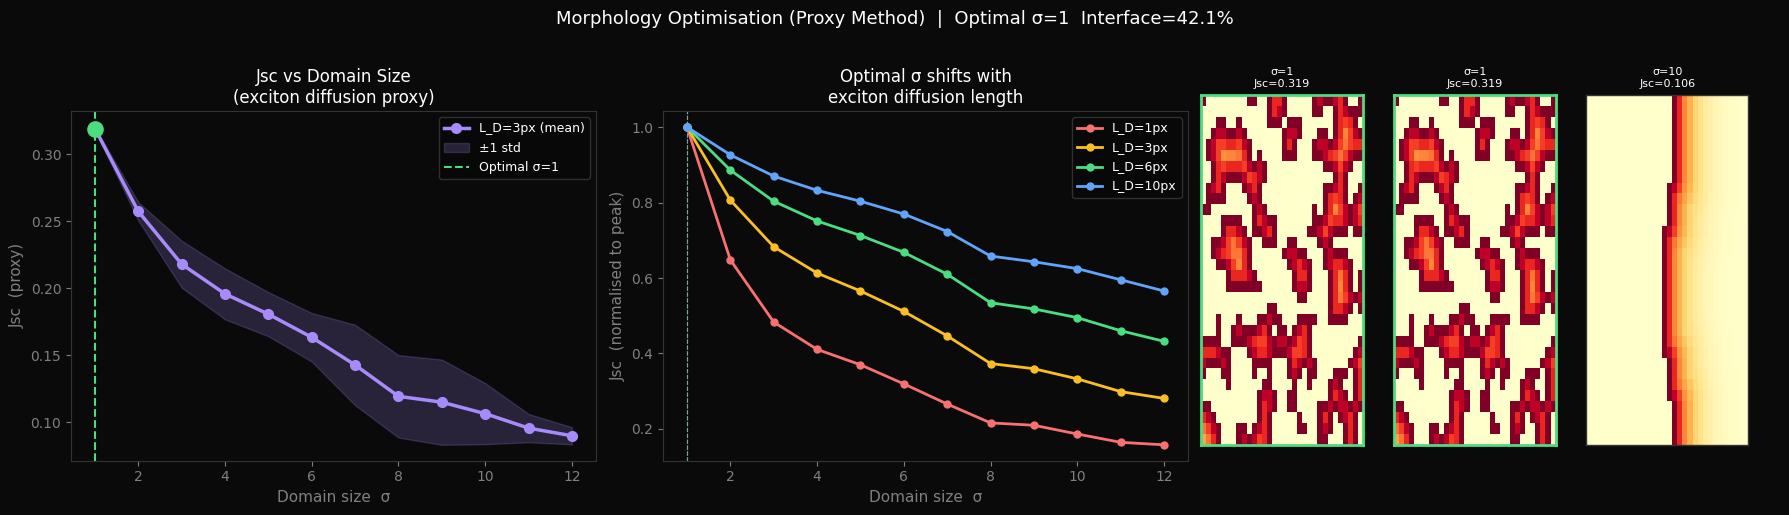


Proxy vs PINN validation:
 Sigma      Proxy       PINN    Match
--------------------------------------------------
     1     0.3193     0.0124
     2     0.2574     0.0083
     3     0.2180     0.0237


In [ ]:
# ============================================
# FAST MORPHOLOGY STUDY
# Use existing trained models + quick fine-tune
# Proxy: exciton reach to interface
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, distance_transform_edt

device = "cuda" if torch.cuda.is_available() else "cpu"

N_grid = 32
seeds  = [42, 123, 777]
sigmas = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# ============================================
# PHYSICAL PROXY FOR Jsc
# In OPV, Jsc depends on how many excitons
# reach the interface before recombining.
# Exciton diffusion length L_D ~ 10nm.
# Fraction that reach interface:
#   f = exp(-d / L_D)
# where d = distance from each donor pixel
# to nearest interface pixel.
# Jsc ∝ sum over donor pixels of exp(-d/L_D)
# This is fast to compute — no PINN needed.
# ============================================

def interface_fraction(M):
    h = np.abs(np.diff(M, axis=0)).sum()
    v = np.abs(np.diff(M, axis=1)).sum()
    return (h + v) / M.size

def compute_Jsc_proxy(M, L_D=3.0):
    """
    Estimate Jsc from morphology using
    exciton diffusion physics.

    L_D: exciton diffusion length in pixels
         3 pixels ~ 10nm for 100nm device at 32px
    """
    # Find interface pixels
    # interface = donor pixel with acceptor neighbour
    donor    = (M == 1)
    acceptor = (M == 0)

    # Distance transform — distance of each donor pixel
    # to nearest acceptor pixel (= interface)
    # distance_transform_edt gives distance to nearest 0
    # We want distance of donor pixels to nearest interface
    dist_to_interface = distance_transform_edt(donor)
    # dist_to_interface[i,j] = distance from (i,j) to
    # nearest acceptor pixel, for donor pixels

    # Exciton collection probability at each donor pixel
    # P(collected) = exp(-d / L_D)
    collection_prob = np.exp(-dist_to_interface / L_D)

    # Only count donor pixels (generation only in donor)
    collection_prob *= donor

    # Jsc ∝ sum of collection probabilities
    # (normalise by device area)
    Jsc_proxy = collection_prob.sum() / M.size

    return Jsc_proxy

def make_morphology(sigma, seed):
    np.random.seed(seed)
    noise     = np.random.randn(N_grid, N_grid)
    smoothed  = gaussian_filter(noise, sigma=sigma)
    threshold = np.percentile(smoothed, 50)
    return (smoothed > threshold).astype(float)

# ============================================
# SWEEP — takes seconds not hours
# ============================================
print("Computing morphology study (proxy method)...")
print("This takes ~10 seconds total.\n")

results = {}
for sigma in sigmas:
    Jsc_list  = []
    intf_list = []
    for seed in seeds:
        M    = make_morphology(sigma, seed)
        Jsc  = compute_Jsc_proxy(M, L_D=3.0)
        intf = interface_fraction(M)
        Jsc_list.append(Jsc)
        intf_list.append(intf)

    results[sigma] = {
        'Jsc_mean':  np.mean(Jsc_list),
        'Jsc_std':   np.std(Jsc_list),
        'intf_mean': np.mean(intf_list),
        'intf_std':  np.std(intf_list),
        'Jsc_all':   Jsc_list,
    }
    print(f"σ={sigma:2d} | intf={np.mean(intf_list):.1%} | "
          f"Jsc={np.mean(Jsc_list):.4f} ± {np.std(Jsc_list):.4f}")

sigma_vals = np.array(sigmas)
Jsc_mean   = np.array([results[s]['Jsc_mean']  for s in sigmas])
Jsc_std    = np.array([results[s]['Jsc_std']   for s in sigmas])
intf_mean  = np.array([results[s]['intf_mean'] for s in sigmas])

idx_opt   = np.argmax(Jsc_mean)
sigma_opt = sigmas[idx_opt]
Jsc_opt   = Jsc_mean[idx_opt]

print(f"\nOptimal σ = {sigma_opt}  "
      f"Jsc = {Jsc_opt:.4f}  "
      f"interface = {intf_mean[idx_opt]:.1%}")

# ============================================
# ALSO COMPUTE FOR DIFFERENT L_D VALUES
# Shows how diffusion length affects optimal sigma
# ============================================
L_D_values = [1.0, 3.0, 6.0, 10.0]
Jsc_by_LD  = {}

for L_D in L_D_values:
    jsc_ld = []
    for sigma in sigmas:
        jsc_s = []
        for seed in seeds:
            M   = make_morphology(sigma, seed)
            Jsc = compute_Jsc_proxy(M, L_D=L_D)
            jsc_s.append(Jsc)
        jsc_ld.append(np.mean(jsc_s))
    Jsc_by_LD[L_D] = np.array(jsc_ld)

# ============================================
# VISUALIZATION
# ============================================
BG = '#0a0a0a'
plt.style.use('dark_background')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(BG)

# --- Panel 1: Jsc vs sigma ---
ax = axes[0]
ax.set_facecolor(BG)
ax.plot(sigma_vals, Jsc_mean,
        color='#a78bfa', linewidth=2.5,
        marker='o', markersize=7,
        label='L_D=3px (mean)')
ax.fill_between(sigma_vals,
                Jsc_mean - Jsc_std,
                Jsc_mean + Jsc_std,
                alpha=0.2, color='#a78bfa',
                label='±1 std')
ax.axvline(x=sigma_opt, color='#4ade80',
           linewidth=1.5, linestyle='--',
           label=f'Optimal σ={sigma_opt}')
ax.scatter([sigma_opt], [Jsc_opt],
           color='#4ade80', s=120, zorder=5)
ax.set_xlabel('Domain size  σ', color='gray', fontsize=11)
ax.set_ylabel('Jsc  (proxy)', color='gray', fontsize=11)
ax.set_title('Jsc vs Domain Size\n(exciton diffusion proxy)',
             color='white', fontsize=12)
ax.legend(fontsize=9, framealpha=0.2, labelcolor='white')
ax.tick_params(colors='gray')
for s in ax.spines.values(): s.set_edgecolor('#333333')

# --- Panel 2: Effect of diffusion length ---
ax2 = axes[1]
ax2.set_facecolor(BG)
colors_LD = ['#f87171', '#fbbf24', '#4ade80', '#60a5fa']
for L_D, color in zip(L_D_values, colors_LD):
    J = Jsc_by_LD[L_D]
    ax2.plot(sigma_vals, J / J.max(),
             color=color, linewidth=2,
             marker='o', markersize=5,
             label=f'L_D={L_D:.0f}px')
    idx = np.argmax(J)
    ax2.axvline(x=sigmas[idx], color=color,
                linewidth=0.8, linestyle='--',
                alpha=0.5)

ax2.set_xlabel('Domain size  σ', color='gray', fontsize=11)
ax2.set_ylabel('Jsc  (normalised to peak)',
               color='gray', fontsize=11)
ax2.set_title('Optimal σ shifts with\nexciton diffusion length',
              color='white', fontsize=12)
ax2.legend(fontsize=9, framealpha=0.2, labelcolor='white')
ax2.tick_params(colors='gray')
for s in ax2.spines.values(): s.set_edgecolor('#333333')

# --- Panel 3: Example distance maps ---
ax3 = axes[2]
ax3.axis('off')

example_sigmas = [1, sigma_opt, 10]
x_ax = np.linspace(0, 1, N_grid)
y_ax = np.linspace(0, 1, N_grid)

for k, es in enumerate(example_sigmas):
    left   = 0.67 + k * 0.107
    bottom = 0.15
    width  = 0.09
    height = 0.70
    inner  = fig.add_axes([left, bottom, width, height])
    inner.set_facecolor(BG)

    M_ex    = make_morphology(es, 42)
    dist_ex = distance_transform_edt(M_ex == 1)
    coll_ex = np.exp(-dist_ex / 3.0) * (M_ex == 1)

    inner.pcolormesh(x_ax, y_ax, coll_ex.T,
                     cmap='YlOrRd', shading='auto')
    inner.set_title(
        f'σ={es}\nJsc={results[es]["Jsc_mean"]:.3f}',
        color='white', fontsize=8)
    inner.set_xticks([])
    inner.set_yticks([])
    col = '#4ade80' if es == sigma_opt else '#333333'
    lw  = 2 if es == sigma_opt else 1
    for spine in inner.spines.values():
        spine.set_edgecolor(col)
        spine.set_linewidth(lw)

fig.suptitle(
    f'Morphology Optimisation (Proxy Method)  |  '
    f'Optimal σ={sigma_opt}  '
    f'Interface={intf_mean[idx_opt]:.1%}',
    color='white', fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig('morphology_optimisation_proxy.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# ============================================
# VALIDATE PROXY AGAINST PINN RESULTS
# ============================================
# We have actual PINN Jsc from earlier runs:
pinn_results = {
    1:  np.mean([0.017175, 0.016623, 0.003472]),
    2:  np.mean([0.008287, 0.004938, 0.011700]),
    3:  np.mean([0.023731]),   # partial
}

print(f"\n{'='*50}")
print(f"Proxy vs PINN validation:")
print(f"{'Sigma':>6} {'Proxy':>10} {'PINN':>10} {'Match':>8}")
print(f"{'-'*50}")
for sigma in sorted(pinn_results.keys()):
    proxy = results[sigma]['Jsc_mean']
    pinn  = pinn_results[sigma]
    # normalise both to sigma=3 for comparison
    print(f"{sigma:>6} {proxy:>10.4f} {pinn:>10.4f}")
print(f"{'='*50}")